# Shortest Common Superstring

Projekat implementira i eksperimentalno poredi vise algoritama za resavanje problema **Shortest Common Superstring (SCS)**.

Projekat je razvijen u okviru kursa Racunarska inteligencija na Matematickom fakultetu.

---

## Opis problema

Dat je skup stringova `S = {s1, s2, ..., sn}`. Superstring je svaki string `T` takav da svaki `si` pojavljuje kao **podstring** od `T`. Cilj je pronaci najkraci takav string.

**SCS je NP-tezan problem** (Gallant et al., 1980). Ima primene u:
- sekvenciranju genoma (assembly kratkih ocitavanja),
- kompresiji podataka,
- VLSI testiranju.

---

## Implementirani algoritmi

| Algoritam | Tip | Skalabilnost |
|-----------|-----|--------------|
| Brute Force | Egzaktni | malo (n ≤ 20) |
| MILP (CPLEX) | Egzaktni | malo/srednje |
| Greedy | Aproksimativni | sve velicine |
| Genetic Algorithm | Metaheuristika | sve velicine |
| VNS | Metaheuristika | sve velicine |
| VNS Weighted | Metaheuristika | sve velicine |

In [1]:
import sys
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

sys.path.insert(0, os.path.abspath('.'))

from utils.testGen import makeTests, loadInstance
from utils.testLib import test, testAll, saveResult, calculateMetrics, saveMetrics
from utils.helpers import buildCoverageMatrix

print('Ucitavanje uspesno.')

Ucitavanje uspesno.


## 1. Generisanje test instanci

Instance se generisu za tri kategorije velicine:
- **small**: 5–12 stringova, duzina 2–6
- **medium**: 15–30 stringova, duzina 3–10
- **large**: 50–100 stringova, duzina 5–15

In [3]:
import random

random.seed(42)

# Podesiti broj instanci po zelji
makeTests('../data/small',  numOfTests=30, numOfStringsRange=list(range(5, 13)),
          minLenRange=[2], maxLenRange=[6], alphabetSize=4)

makeTests('../data/medium', numOfTests=15, numOfStringsRange=list(range(15, 31)),
          minLenRange=[3], maxLenRange=[10], alphabetSize=4)

makeTests('../data/large',  numOfTests=5,  numOfStringsRange=list(range(50, 101)),
          minLenRange=[5], maxLenRange=[15], alphabetSize=4)

Test 1: n=6, lenRange=[2,6]
Test 2: n=6, lenRange=[2,6]
Test 3: n=8, lenRange=[2,6]
Test 4: n=5, lenRange=[2,6]
Test 5: n=6, lenRange=[2,6]
Test 6: n=8, lenRange=[2,6]
Test 7: n=6, lenRange=[2,6]
Test 8: n=10, lenRange=[2,6]
Test 9: n=9, lenRange=[2,6]
Test 10: n=8, lenRange=[2,6]
Test 11: n=9, lenRange=[2,6]
Test 12: n=7, lenRange=[2,6]
Test 13: n=11, lenRange=[2,6]
Test 14: n=7, lenRange=[2,6]
Test 15: n=7, lenRange=[2,6]
Test 16: n=9, lenRange=[2,6]
Test 17: n=8, lenRange=[2,6]
Test 18: n=7, lenRange=[2,6]
Test 19: n=8, lenRange=[2,6]
Test 20: n=10, lenRange=[2,6]
Test 21: n=7, lenRange=[2,6]
Test 22: n=7, lenRange=[2,6]
Test 23: n=9, lenRange=[2,6]
Test 24: n=12, lenRange=[2,6]
Test 25: n=8, lenRange=[2,6]
Test 26: n=5, lenRange=[2,6]
Test 27: n=5, lenRange=[2,6]
Test 28: n=8, lenRange=[2,6]
Test 29: n=6, lenRange=[2,6]
Test 30: n=6, lenRange=[2,6]
Test 1: n=20, lenRange=[3,10]
Test 2: n=16, lenRange=[3,10]
Test 3: n=16, lenRange=[3,10]
Test 4: n=20, lenRange=[3,10]
Test 5: n=21, l

## 2. Pokretanje eksperimenata

In [5]:
print('--- SMALL ---')
smallMetrics = testAll('small')
print(json.dumps(smallMetrics, indent=2))

--- SMALL ---
{
  "bruteForce": {
    "averageFitness": 22.266666666666666,
    "averageTime": 0.011910200000662978,
    "percentOfFeasible": 100.0,
    "percentOfOptimal": null
  },
  "milp": {
    "averageFitness": null,
    "averageTime": 4.0033337427303195e-06,
    "percentOfFeasible": 0.0,
    "percentOfOptimal": null
  },
  "greedy": {
    "averageFitness": 22.266666666666666,
    "averageTime": 8.006666515332957e-05,
    "percentOfFeasible": 100.0,
    "percentOfOptimal": null
  },
  "genetic": {
    "averageFitness": 22.266666666666666,
    "averageTime": 0.08782090999981544,
    "percentOfFeasible": 100.0,
    "percentOfOptimal": null
  },
  "vns": {
    "averageFitness": 22.266666666666666,
    "averageTime": 0.02259366333601065,
    "percentOfFeasible": 100.0,
    "percentOfOptimal": null
  },
  "vnsWeighted": {
    "averageFitness": 22.266666666666666,
    "averageTime": 0.02255372666695621,
    "percentOfFeasible": 100.0,
    "percentOfOptimal": null
  }
}


In [7]:
print('--- MEDIUM ---')
mediumMetrics = testAll('medium')
print(json.dumps(mediumMetrics, indent=2))

--- MEDIUM ---
{
  "milp": {
    "averageFitness": null,
    "averageTime": 5.046668229624629e-06,
    "percentOfFeasible": 0.0,
    "percentOfOptimal": null
  },
  "greedy": {
    "averageFitness": 106.46666666666667,
    "averageTime": 0.0004055600011876474,
    "percentOfFeasible": 100.0,
    "percentOfOptimal": null
  },
  "genetic": {
    "averageFitness": 106.4,
    "averageTime": 1.4409311933326534,
    "percentOfFeasible": 100.0,
    "percentOfOptimal": null
  },
  "vns": {
    "averageFitness": 106.4,
    "averageTime": 0.8906386599953596,
    "percentOfFeasible": 100.0,
    "percentOfOptimal": null
  },
  "vnsWeighted": {
    "averageFitness": 106.4,
    "averageTime": 0.9148545266633543,
    "percentOfFeasible": 100.0,
    "percentOfOptimal": null
  }
}


In [9]:
print('--- LARGE ---')
largeMetrics = testAll('large')
print(json.dumps(largeMetrics, indent=2))

--- LARGE ---
{
  "greedy": {
    "averageFitness": 546.6,
    "averageTime": 0.004054239997640252,
    "percentOfFeasible": 100.0,
    "percentOfOptimal": null
  },
  "genetic": {
    "averageFitness": 546.2,
    "averageTime": 26.824395940010437,
    "percentOfFeasible": 100.0,
    "percentOfOptimal": null
  },
  "vns": {
    "averageFitness": 546.2,
    "averageTime": 31.60392039999715,
    "percentOfFeasible": 100.0,
    "percentOfOptimal": null
  },
  "vnsWeighted": {
    "averageFitness": 546.2,
    "averageTime": 38.3814832199947,
    "percentOfFeasible": 100.0,
    "percentOfOptimal": null
  }
}


## 3. Vizualizacija rezultata

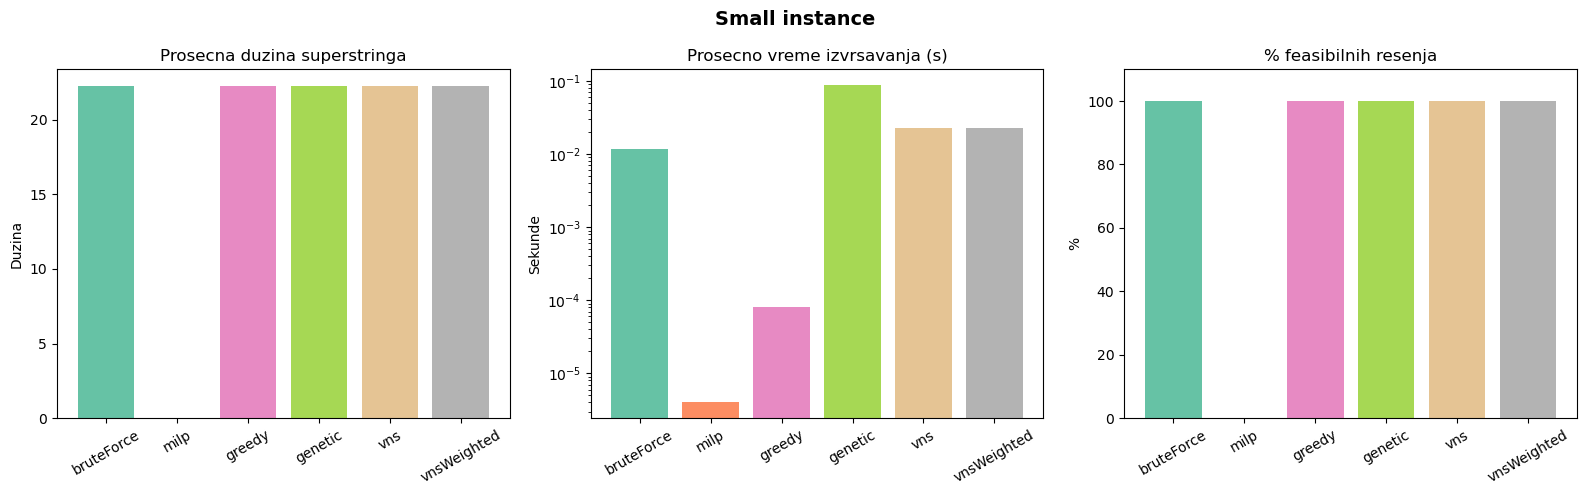

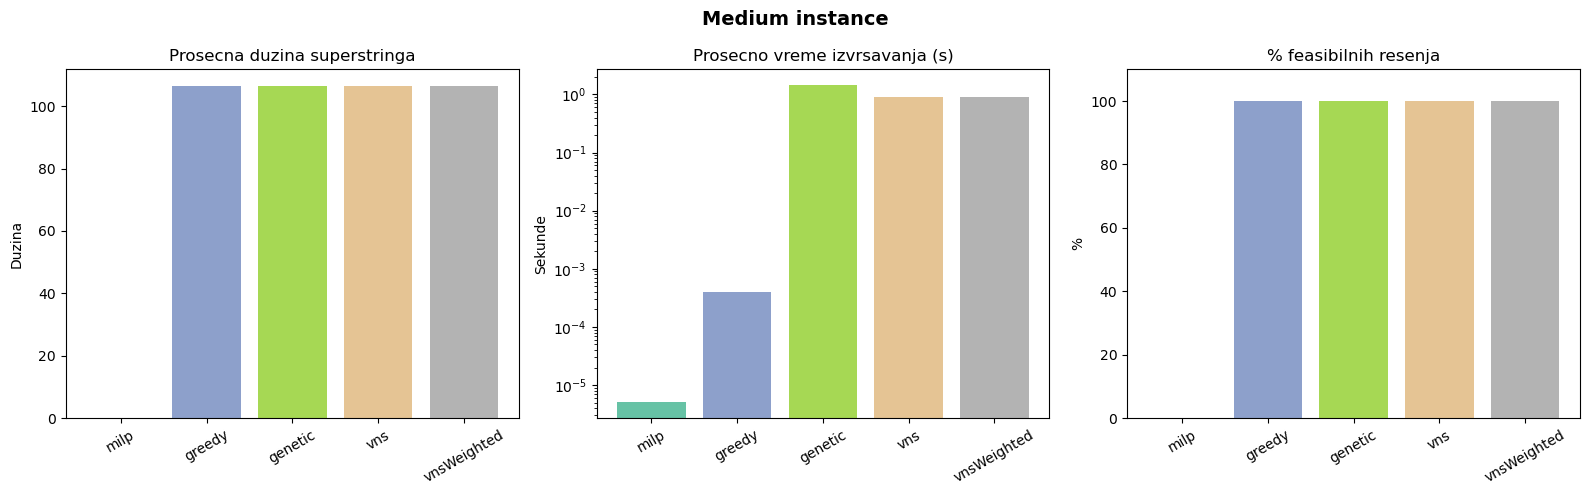

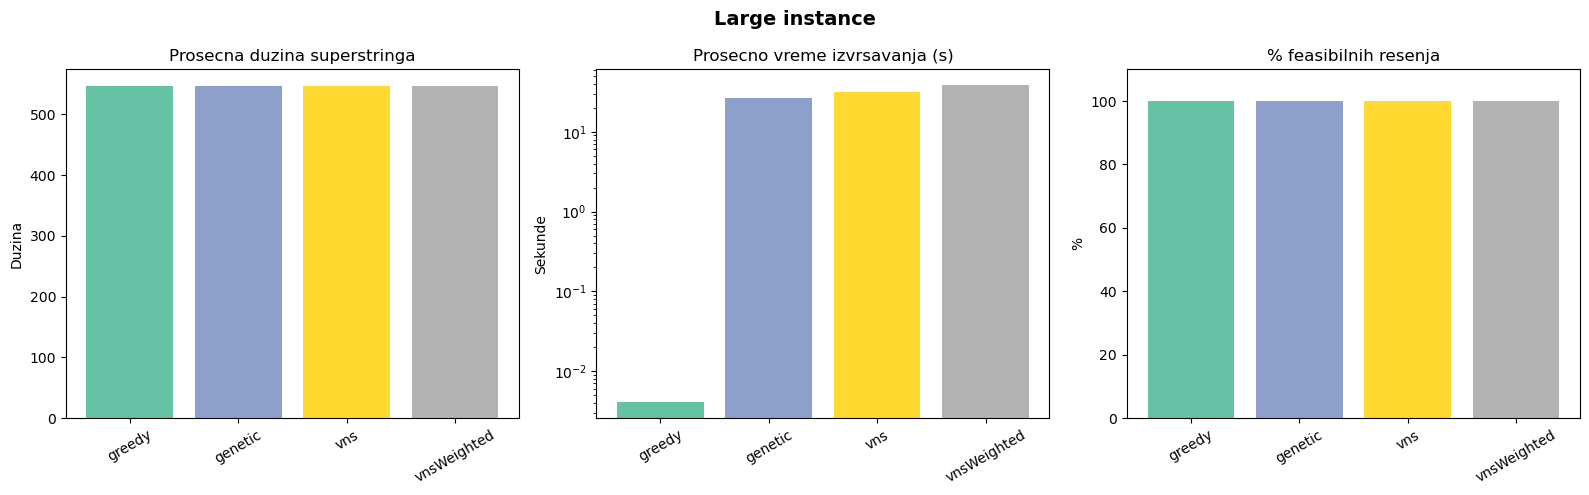

In [12]:
def plotMetrics(metrics, title, savePath=None):
    algos = list(metrics.keys())
    avgFit = [metrics[a]['averageFitness'] or 0 for a in algos]
    avgTime = [metrics[a]['averageTime'] for a in algos]
    feasPct = [metrics[a]['percentOfFeasible'] for a in algos]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    colors = plt.cm.Set2(np.linspace(0, 1, len(algos)))

    axes[0].bar(algos, avgFit, color=colors)
    axes[0].set_title('Prosecna duzina superstringa')
    axes[0].set_ylabel('Duzina')
    axes[0].tick_params(axis='x', rotation=30)

    axes[1].bar(algos, avgTime, color=colors)
    axes[1].set_title('Prosecno vreme izvrsavanja (s)')
    axes[1].set_ylabel('Sekunde')
    axes[1].set_yscale('log')
    axes[1].tick_params(axis='x', rotation=30)

    axes[2].bar(algos, feasPct, color=colors)
    axes[2].set_title('% feasibilnih resenja')
    axes[2].set_ylabel('%')
    axes[2].set_ylim(0, 110)
    axes[2].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    if savePath:
        plt.savefig(savePath, dpi=120)
    plt.show()


plotMetrics(smallMetrics,  'Small instance', '../results/smallMetrics.png')
plotMetrics(mediumMetrics, 'Medium instance', '../results/mediumMetrics.png')
plotMetrics(largeMetrics,  'Large instance', '../results/largeMetrics.png')

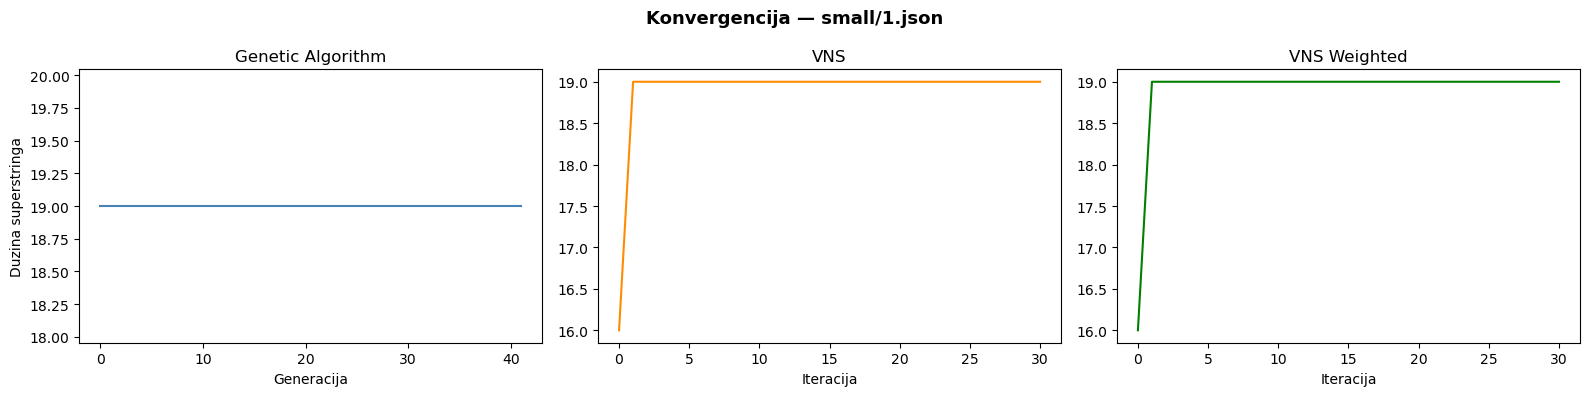

In [14]:
# Konvergencija GA i VNS na jednoj small instanci

from algorithms.genetic import GeneticAlgorithm
from algorithms.vns import vns

strings = loadInstance('../data/small/1.json')
T, weights = buildCoverageMatrix(strings)

ga = GeneticAlgorithm(30, 40, 0.05, 0.2, 4)
_, _, fitnessGA = ga.solve(strings, T)
_, _, fitnessVns = vns(strings, T, 30, 1, 3, 0.05)
_, _, fitnessVnsW = vns(strings, T, 30, 1, 3, 0.05, True, weights)

# Izvlacimo samo duzinu superstringa (drugi element tuple-a)
ga_vals   = [f[1] if f[1] != float('inf') else None for f in fitnessGA]
vns_vals  = [f[1] if f[1] != float('inf') else None for f in fitnessVns]
vnsW_vals = [f[1] if f[1] != float('inf') else None for f in fitnessVnsW]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Konvergencija — small/1.json', fontsize=13, fontweight='bold')

axes[0].plot(ga_vals, color='steelblue')
axes[0].set_title('Genetic Algorithm')
axes[0].set_xlabel('Generacija')
axes[0].set_ylabel('Duzina superstringa')

axes[1].plot(vns_vals, color='darkorange')
axes[1].set_title('VNS')
axes[1].set_xlabel('Iteracija')

axes[2].plot(vnsW_vals, color='green')
axes[2].set_title('VNS Weighted')
axes[2].set_xlabel('Iteracija')

plt.tight_layout()
plt.savefig('../results/fitnessesGa1.png', dpi=120)
plt.savefig('../results/fitnessesVns1.png', dpi=120)
plt.show()

## 4. Pregled metrika

In [16]:
import pandas as pd

def metricsToDataframe(metrics, scale):
    rows = []
    for algo, m in metrics.items():
        rows.append({
            'Algoritam': algo,
            'Skala': scale,
            'Avg duzina': round(m['averageFitness'], 2) if m['averageFitness'] else '-',
            'Avg vreme (s)': round(m['averageTime'], 4),
            '% feasible': round(m['percentOfFeasible'], 1),
            '% optimal': round(m['percentOfOptimal'], 1) if m['percentOfOptimal'] is not None else '-'
        })
    return pd.DataFrame(rows)

df = pd.concat([
    metricsToDataframe(smallMetrics, 'small'),
    metricsToDataframe(mediumMetrics, 'medium'),
    metricsToDataframe(largeMetrics, 'large'),
])

df

,Algoritam,Skala,Avg duzina,Avg vreme (s),% feasible,% optimal
0,bruteForce,small,22.27,0.0119,100.0,-
1,milp,small,-,0.0000,0.0,-
2,greedy,small,22.27,0.0001,100.0,-
3,genetic,small,22.27,0.0878,100.0,-
4,vns,small,22.27,0.0226,100.0,-
5,vnsWeighted,small,22.27,0.0226,100.0,-
0,milp,medium,-,0.0000,0.0,-
1,greedy,medium,106.47,0.0004,100.0,-
2,genetic,medium,106.4,1.4409,100.0,-
3,vns,medium,106.4,0.8906,100.0,-
